# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs) 
3. sapphire.run(parameters) 

In [1]:
import sapphire 

In [2]:
# define parameters dict as in test_run.py, and then call sapphire.run(parameters) and work with resulting objects interactively 

parameters = {'output_file':'/mnt/ceph/users/vpandya/test_tng.npz', # name of output file, NOTE: this will be rewritten as a directory location, and our I/O module will take care writing
              'tree_type':'tng', # type of trees -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/ceph/users/rsomerville/TNG-SAM/L35n2160TNG/isotrees/isotree_0_0_0.dat', # either directory containing tree files or path to single tree file itself in case of TNG experimentation
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'min_root_mass':1e9, # relevant for TNG, not for FIRE
              'parallelize_read_trees':False, # whether to use parallelization to read in (and interpolate) merger tree files
              'parallelize_integration':False, # whether to use paralelization to integrate the evolution of every halo
              'parallelize_mode':None, # whether to use multiprocessing or mpi4py for parallelization (default: None)
              'parallelize_options':None, # list of optional args for multiprocessing or mpi4py such as number of nodes, cores, etc. (default: None)
              'parameter_functions':'fire2', # name of module in parameter_functions with fitting functions for free parameters
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'Rturb_transition':7.0, # time in Gyr where Rturb logistic function drops to ~half its max value
              'Rturb_slope':2.0, # exponential slope for smoothness/abruptness of Rturb logistic transition
              'f_supp':1.0, # multiply vturb in tff,eff by this to get more turb pressure support for a given vturb
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'Rturb_type':'RvirLogistic', # either Rvir so Rturb(t)=Rvir(t), or fiducial Rvir-->Rmax logistic from Pandya+22
              'verbose':False, # whether to print values of several properties at each timestep of integration (for debugging)
              'return_all':False} # False for initial solve_ivp call; will be re-run with True to store ALL properties for output 


In [8]:
%%prun -s cumulative # I am optionally including this magic function so at the end ipynb will print code profiling/timing details
sapphire.run(parameters)

Parsing input parameters...
Reading trees...


Loading tree roots: 100%|██████████| 2099108341/2099108341 [00:05<00:00, 358351555.34it/s]


Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/m

<!----- WARNING: solve_ivp exited with error for halo_name=1559929366


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/phy

Saving outputs...
Finished -- thank you for using sapphire!
 

         232259891 function calls (229018640 primitive calls) in 493.243 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  493.243  493.243 {built-in method builtins.exec}
        1    0.968    0.968  493.243  493.243 <string>:1(<module>)
        1    0.001    0.001  492.273  492.273 driver.py:21(run)
        1    0.006    0.006  310.090  310.090 read_tng.py:21(read_trees)
689226/244726    0.292    0.000  263.058    0.001 tree_node.py:248(__getitem__)
689226/244726    1.917    0.000  262.943    0.001 tree_node.py:254(query)
   250171   50.505    0.000  213.530    0.001 io.py:30(_read_fields)
   689226    4.577    0.000  195.595    0.000 io.py:99(get_fields)
784182/780397    0.413    0.000  152.173    0.000 {built-in method numpy.core._multiarray_umath.implement_array_function}
        1    0.000    0.000  150.464  150.464 <__array_function__ internals>:177(savez_compressed)
        1    0.000   

# let's test running on FIRE-2 Pandya+22 format "trees"

In [3]:
# define parameters dict as in test_run.py, and then call sapphire.run(parameters) and work with resulting objects interactively 

# everything in parameters dict will stay the same except options related to input/output data locations 

parameters['output_file'] = '/mnt/ceph/users/vpandya/test_fire2_sapphire.npz'
parameters['tree_type'] = 'fire2_sapphire'
parameters['tree_path'] = '/mnt/ceph/users/vpandya/trees_fire/'
parameters['halo_names'] = None 


In [4]:
%%prun -s cumulative # I am optionally including this magic function so at the end ipynb will print code profiling/timing details
sapphire.run(parameters)

Parsing input parameters...
Reading trees...
Interpolating trees...
Setting up model inputs and parameters...
Evolving model halos...
we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: inv

Saving outputs...
Finished -- thank you for using sapphire!
 

         390966 function calls (379479 primitive calls) in 9.202 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      9/1    0.000    0.000    9.202    9.202 {built-in method builtins.exec}
        1    0.022    0.022    9.202    9.202 <string>:1(<module>)
        1    0.000    0.000    9.178    9.178 driver.py:21(run)
      262    0.024    0.000    4.402    0.017 threading.py:582(wait)
      262    0.002    0.000    4.377    0.017 threading.py:288(wait)
     1829    4.376    0.002    4.376    0.002 {method 'acquire' of '_thread.lock' objects}
        1    0.000    0.000    4.295    4.295 pool.py:359(map)
        1    0.000    0.000    4.295    4.295 pool.py:764(get)
        1    0.000    0.000    4.295    4.295 pool.py:761(wait)
  452/302    0.000    0.000    3.216    0.011 {built-in method numpy.core._multiarray_umath.implement_array_function}
        1    0.000    0.000    3.211    3.211 <__array_function__ internals>

# For debugging you can also use the %run magic function on a python script that uses sapphire

In [1]:
# first execute test_run.py again with detailed code profiling: timing, function calls, etc.
%run -p -s cumulative test_run.py

/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:145: RuntimeWarning: divide by zero encountered in double_scalars
  tturb_cgm = (Rturb / (vturb_cgm*1e5*cm_to_kpc)) * s_to_yr*1e-9 # Gyr
/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: divide by zero encountered in log10
  np.log10(Tval),
/opt/anaconda3/envs/sapphire/lib/python3.10/site-packages/scipy/interpolate/_rgi.py:358: RuntimeWarning: invalid value encountered in add
  values += np.asarray(self.values[edge_indices]) * weight[vslice]
/opt/anaconda3/envs/sapphire/lib/python3.10/site-packages/scipy/interpolate/_rgi.py:357: RuntimeWarning: invalid value encountered in multiply
  weight *= np.where(ei == i, 1 - yi, yi)
/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:212: RuntimeWar

>>>>> FINISHED halo=m10q


/Users/viraj/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),


>>>>> FINISHED halo=m11c
>>>>> FINISHED halo=m12m
Finished -- thank you for using sapphire!
          7053060 function calls (6863651 primitive calls) in 10.841 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    798/1    0.004    0.000   10.842   10.842 {built-in method builtins.exec}
        1    0.000    0.000   10.842   10.842 interactiveshell.py:2753(safe_execfile)
        1    0.000    0.000   10.841   10.841 py3compat.py:51(execfile)
        1    0.005    0.005   10.840   10.840 test_run.py:1(<module>)
        1    0.001    0.001    9.801    9.801 driver.py:19(run)
        3    0.001    0.000    9.244    3.081 fiducial_model.py:331(integrator)
     7589    0.564    0.000    8.887    0.001 fiducial_model.py:35(evolve_galaxy)
        3    0.004    0.001    5.689    1.896 ivp.py:156(solve_ivp)
      906    0.003    0.000    5.614    0.006 base.py:159(step)
      906    0.042    0.000    5.611    0.006 bdf.py:300(_step

In [2]:
# now again execute test_run.py, tell us how long total script takes, AND let us continue to have interactive access to any variables 
%run -t test_run.py

>>>>> FINISHED halo=m10q
>>>>> FINISHED halo=m11c
>>>>> FINISHED halo=m12m
Finished -- thank you for using sapphire!

IPython CPU timings (estimated):
  User   :       8.09 s.
  System :       0.08 s.
Wall time:       8.17 s.


In [3]:
# if this does not raise any assertion error messages, it means the tests were succesful 
%run -t test_validate.py


IPython CPU timings (estimated):
  User   :       0.49 s.
  System :       0.03 s.
Wall time:       0.55 s.


In [5]:
# let's go back and overplot time series of test vs. reference solutions for each of the state variables and their associated derivatives

%matplotlib inline 
import matplotlib.pyplot as plt 
plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [15]:
### make sure we still have interactive access to the npz_test and npz_ref solution objects defined in test_run.py 
npz_test, npz_ref # if these are not defined, we will get an error, otherwise we are fine

### and also the test_vars list of variables from test_validation.py that we asserted be equal to each other
print(test_vars) 

['cosmic_age', 'redshift', 'M_cgm', 'Mdot_cgm', 'M_ism', 'Mdot_ism', 'M_star', 'Mdot_sfr', 'Eth_cgm', 'Edot_cgm_th', 'Ekin_cgm', 'Edot_cgm_kin', 'MZ_cgm', 'MZdot_cgm', 'MZ_ism', 'MZdot_ism', 'MZ_star', 'MZdot_star']


In [10]:
# choose one of m10q, m11c or m12m and we will create a plot just for that halo alone
halo_name = 'm12m'

# access this halo's test and reference solution from the files already generated by test_run.py and read in by test_validate.py 
halo_test = npz_test[halo_name].item()
halo_ref = npz_ref[halo_name].item()

halo_sols = [halo_test,halo_ref]

(0.001, 1.7573683959750261)

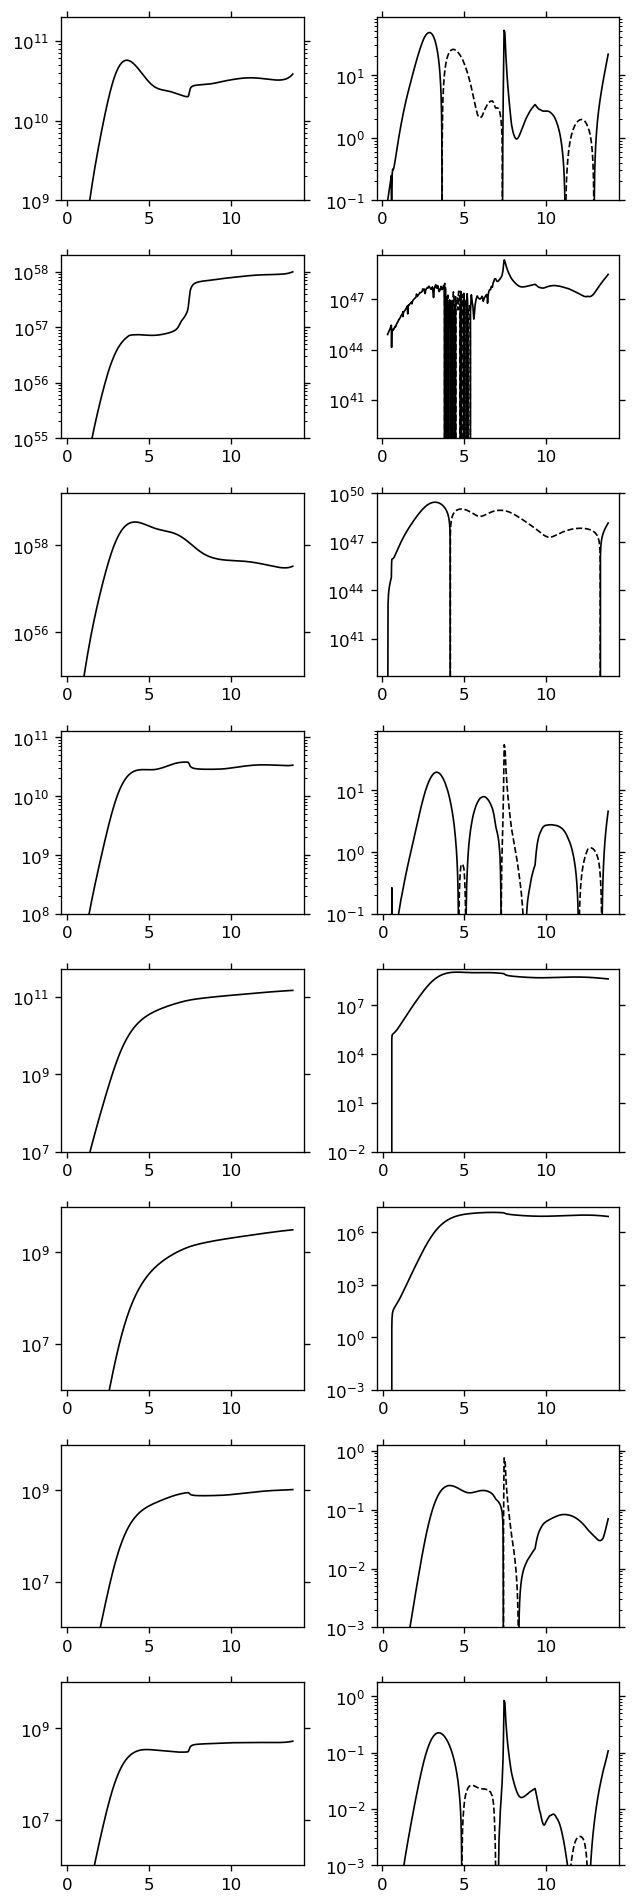

In [16]:
### Set up plot y-axis limits for m10, m11 and m12 halos -- masses, Mdots, energies, Edots
ylims_mcgm = {'m10':(1e7,None),'m11':(1e8,None),'m12':(1e9,None)}
ylims_mism = {'m10':(1e5,None),'m11':(1e7,None),'m12':(1e8,None)}
ylims_mstar = {'m10':(5e4,None),'m11':(1e6,None),'m12':(1e7,None)}
ylims_mdots = {'m10':(1e-3,None),'m11':(1e-2,None),'m12':(1e-1,None)}
ylims_sfr = {'m10':(1e-5,None),'m11':(1e-3,None),'m12':(1e-2,None)}
ylims_ecgm = {'m10':(1e52,None),'m11':(1e54,None),'m12':(1e55,None)}
ylims_edots = {'m10':(1e35,None),'m11':(1e37,5e41),'m12':(5e38,None)}
ylims_zdots = {'m10':(1e-7,None),'m11':(1e-4,None),'m12':(1e-3,None)}
ylims_Zmet = {'m10':(1e-4,1e0),'m11':(1e-4,1e0),'m12':(1e-3,5e0)}
ylims_Mmet = {'m10':(1e2,1e6),'m11':(1e5,1e9),'m12':(1e6,1e10)}

# define constants and units that we may need with astropy 
from astropy import units as u 
s_to_yr = u.s.to('yr') # NOTE: currently sapphire natively outputs Mdot's in Msun/sec, but we will plot Msun/yr

##### Plot state variables and the LHS of their corresponding ODEs vs time
##### dashed lines mean negative derivatives 

fig, axes = plt.subplots(nrows=8,ncols=2,figsize=(6,20))
fig.subplots_adjust(wspace=0.3,hspace=0.3)
allax = np.ravel(axes)

for ax in allax:
    ax.set_yscale('log')

axes[0][0].plot(halo_test['cosmic_age'],halo_test['M_cgm'],'k-',lw=1)
axes[0][0].set_ylim(ylims_mcgm[halo_name[:3]])

axes[0][1].plot(halo_test['cosmic_age'],np.array(halo_test['Mdot_cgm'])/s_to_yr,'k-',lw=1)
axes[0][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Mdot_cgm'])/s_to_yr,'k--',lw=1)
axes[0][1].set_ylim(ylims_mdots[halo_name[:3]])

axes[1][0].plot(halo_test['cosmic_age'],halo_test['Eth_cgm'],'k-',lw=1)
axes[1][0].set_ylim(ylims_ecgm[halo_name[:3]])

axes[1][1].plot(halo_test['cosmic_age'],np.array(halo_test['Edot_cgm_th'])/s_to_yr,'k-',lw=1)
axes[1][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Edot_cgm_th'])/s_to_yr,'k--',lw=1)
axes[1][1].set_ylim(ylims_edots[halo_name[:3]])

axes[2][0].plot(halo_test['cosmic_age'],halo_test['Ekin_cgm'],'k-',lw=1)
axes[2][0].set_ylim(ylims_ecgm[halo_name[:3]])

axes[2][1].plot(halo_test['cosmic_age'],np.array(halo_test['Edot_cgm_kin'])/s_to_yr,'k-',lw=1)
axes[2][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Edot_cgm_kin'])/s_to_yr,'k--',lw=1)
axes[2][1].set_ylim(ylims_edots[halo_name[:3]])

axes[3][0].plot(halo_test['cosmic_age'],halo_test['M_ism'],'k-',lw=1)
axes[3][0].set_ylim(ylims_mism[halo_name[:3]])

axes[3][1].plot(halo_test['cosmic_age'],np.array(halo_test['Mdot_ism'])/s_to_yr,'k-',lw=1)
axes[3][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Mdot_ism'])/s_to_yr,'k--',lw=1)
axes[3][1].set_ylim(ylims_mdots[halo_name[:3]])

axes[4][0].plot(halo_test['cosmic_age'],halo_test['M_star'],'k-',lw=1)
axes[4][0].set_ylim(ylims_mstar[halo_name[:3]])

axes[4][1].plot(halo_test['cosmic_age'],np.array(halo_test['Mdot_sfr'])/s_to_yr,'k-',lw=1)
axes[4][1].plot(halo_test['cosmic_age'],-np.array(halo_test['Mdot_sfr'])/s_to_yr,'k--',lw=1)
axes[4][1].set_ylim(ylims_sfr[halo_name[:3]])

axes[5][0].plot(halo_test['cosmic_age'],halo_test['MZ_star'],'k-',lw=1)
axes[5][0].set_ylim(ylims_Mmet[halo_name[:3]])

axes[5][1].plot(halo_test['cosmic_age'],np.array(halo_test['MZdot_sfr'])/s_to_yr,'k-',lw=1)
axes[5][1].plot(halo_test['cosmic_age'],-np.array(halo_test['MZdot_sfr'])/s_to_yr,'k--',lw=1)
axes[5][1].set_ylim(ylims_zdots[halo_name[:3]])

axes[6][0].plot(halo_test['cosmic_age'],halo_test['MZ_ism'],'k-',lw=1)
axes[6][0].set_ylim(ylims_Mmet[halo_name[:3]])

axes[6][1].plot(halo_test['cosmic_age'],np.array(halo_test['MZdot_ism'])/s_to_yr,'k-',lw=1)
axes[6][1].plot(halo_test['cosmic_age'],-np.array(halo_test['MZdot_ism'])/s_to_yr,'k--',lw=1)
axes[6][1].set_ylim(ylims_zdots[halo_name[:3]])

axes[7][0].plot(halo_test['cosmic_age'],halo_test['MZ_cgm'],'k-',lw=1)
axes[7][0].set_ylim(ylims_Mmet[halo_name[:3]])

axes[7][1].plot(halo_test['cosmic_age'],np.array(halo_test['MZdot_cgm'])/s_to_yr,'k-',lw=1)
axes[7][1].plot(halo_test['cosmic_age'],-np.array(halo_test['MZdot_cgm'])/s_to_yr,'k--',lw=1)
axes[7][1].set_ylim(ylims_zdots[halo_name[:3]])

In [8]:
from functools import partial

def ptest(x,y,z=5):
    x0,x1 = x
    print(x0+x1+y+z)
    
ptest((1,2),3,4)

ptest2 = partial(ptest,y=1,z=10)
ptest2((1,2))

10
14


# Jan 4, 2023: testing manually on rusty for new TNG tree reader function

In [1]:
# make sure you've added the sapphire code directory to PYTHONPATH in .bashrc/.zshrc (until we provide an option to pip install to site-packages)
import sys
sys.path

['/mnt/ceph/users/vpandya/sapphire/tests',
 '/mnt/ceph/users/vpandya/sapphire',
 '/mnt/home/vpandya/miniconda3/envs/sapphire/lib/python310.zip',
 '/mnt/home/vpandya/miniconda3/envs/sapphire/lib/python3.10',
 '/mnt/home/vpandya/miniconda3/envs/sapphire/lib/python3.10/lib-dynload',
 '',
 '/mnt/home/vpandya/miniconda3/envs/sapphire/lib/python3.10/site-packages']

In [1]:
from sapphire.read_trees import read_tng, read_fire2_sapphire, interpolate_trees
from sapphire.parameter_functions import fire2 as param_functions 
from sapphire.parameter_functions import uvb_filtering
from sapphire.coolfunc import read_coolfunc 
from sapphire.physical_models import fiducial_model 

import multiprocessing
import numpy as np
from functools import partial

In [2]:
tree_tables = read_fire2_sapphire.read_trees(tree_path='/mnt/ceph/users/vpandya/trees_fire')

In [2]:
%%time 
tree_tables = read_tng.read_trees(tree_path='/mnt/ceph/users/rsomerville/TNG-SAM/L35n2160TNG/isotrees/isotree_0_0_0.dat',min_root_mass=1e9)

Additional features and improved performance (usually) by saving this arbor with "save_arbor" and reloading:
	>>> a = ytree.load("/mnt/ceph/users/rsomerville/TNG-SAM/L35n2160TNG/isotrees/isotree_0_0_0.dat")
	>>> fn = a.save_arbor()
	>>> a = ytree.load(fn)


Loading tree roots: 100%|██████████| 2099108341/2099108341 [00:04<00:00, 478244783.34it/s]


CPU times: user 2min 27s, sys: 15.4 s, total: 2min 42s
Wall time: 4min 14s


In [9]:
tree_tables

{1559778421: <Table length=87>
   haloID   root_haloID   redshift  ...  log_cNFW   log_vvir  dm_accretion_rate  
   int64       int64      float32   ...  float32    float32        float64       
 ---------- ----------- ----------- ... ---------- --------- --------------------
  173965714  1559778421   6.0106564 ...  0.5917712 1.0540243  0.33140071114205205
  194429275  1559778421   5.8465014 ... 0.83348495  1.082854   0.6839703874958021
  215356539  1559778421    5.529546 ...  0.4834369 1.1663142  0.04184630375036543
  236642654  1559778421   5.2274256 ... 0.41832328 1.1605284   1.0799550721720579
  258405228  1559778421    4.995923 ...  0.9111398 1.2262999   1.0285572897914357
  280212211  1559778421   4.6644387 ...  0.7303954 1.2833009   0.9057616535790455
  302295160  1559778421   4.4279976 ... 0.62232417 1.3087335   0.5489662031729615
  324362872  1559778421   4.1767874 ... 0.64538366 1.3191775   0.2788072958725496
  346665372  1559778421    4.008013 ... 0.56863517 1.3191204   1.08

In [3]:
tree_interpolators = interpolate_trees.run(tree_tables)

In [11]:
tree_interpolators

{1559778421: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x1551104021d0>,
 1559778530: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110402530>,
 1559778652: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110402b60>,
 1559808566: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110402dd0>,
 1559808732: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110403040>,
 1559808756: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x1551104032b0>,
 1559808813: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110403520>,
 1559808934: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110403790>,
 1559808935: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110403a00>,
 1559809070: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155110403c70>,
 1559809133: [<scipy.interpolate._fitpack2.InterpolatedUnivariateSpline at 0x155

In [4]:
len(tree_interpolators)

605

In [5]:
# retrieve the list of parameter fitting functions in the order expected for unpacking by the integrator
list_param_functions = param_functions.get()

# retrieve the list of UVB filtering mass and collapse fraction functions
list_uvb_filtering = uvb_filtering.get()

# read cooling function and create N-dimensional interpolator object
coolfunc = read_coolfunc.return_coolfunc('wiersma09')

# finally solve for the baryonic evolution of each tree and collect the resulting dict objects into a dict with halo_names/IDs being the keys
# NOTE: this can and should be parallelized, along with the read_trees and interpolate_trees steps 
dict_results = {}

# a subset of parameters needed by fiducial_model
parameters = {'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'Rturb_transition':7.0, # time in Gyr where Rturb logistic function drops to ~half its max value
              'Rturb_slope':2.0, # exponential slope for smoothness/abruptness of Rturb logistic transition
              'f_supp':1.0, # multiply vturb in tff,eff by this to get more turb pressure support for a given vturb
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm              
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'Rturb_type':'RvirLogistic', # either Rvir so Rturb(t)=Rvir(t), or fiducial Rvir-->Rmax logistic from Pandya+22
              'verbose':False, # whether to print values of several properties at each timestep of integration (for debugging)
              'return_all':False} # False for initial solve_ivp call; will be re-run with True to store ALL properties for output 


In [6]:
pool_integrator = partial(fiducial_model.integrator,parameters=parameters,parameter_functions=list_param_functions,uvb_model=list_uvb_filtering,coolfunc=coolfunc)

In [7]:
halo_data_tuples = [(k,v) for k,v in tree_interpolators.items()]

In [8]:
# set up for python single-node parallel processing
PoolProcesses = multiprocessing.cpu_count()
print('we will process %s trees in parallel'%PoolProcesses,flush=True)

# start pool process 
pool = multiprocessing.Pool(processes=PoolProcesses) 

# call the pool_integrator function in parallel with each pair in halo_data_tuples as inputs
out = pool.map(pool_integrator,halo_data_tuples)

# close pool processes to free memory
pool.close()
pool.join()

print('Finished!')

we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/m

<!----- WARNING: solve_ivp exited with error for halo_name=1559929366


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid value encountered in log10
  np.log10(nval)] for (Tval,nval) in list(zip(T_rarr,n_rarr))]) # erg/s * cm**3
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:128: RuntimeWarning: invalid value encountered in log10
  log_Zcgm = np.log10(MZ_cgm / M_cgm / 0.02)
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:164: RuntimeWarning: invalid va

Finished!


In [12]:
import shutil

halo_names = ['m10q','m10y','m10z','m11a','m11b','m11c','m11q','m11v','m11f','m12i','m12f','m12m']

for halo_name in halo_names:
    shutil.copyfile('/mnt/ceph/users/vpandya/protosam/cgm_models/merge_catalogs_offline_%s_stampede2.dat'%halo_name,
                    '/mnt/ceph/users/vpandya/trees_fire/pandya22_%s.dat'%halo_name)


In [9]:
# collapse the list of dicts into a single dict with halo_name:results_dict pairs 
dict_results = {key:value for d in out for key,value in d.items()}

In [15]:
%%time

def evolve_halo(halo_name):
    
    try:
        comb_dict = fiducial_model.integrator(parameters,tree_interpolators[halo_name],list_param_functions,list_uvb_filtering,coolfunc)
        #print('solver completed for halo_name=%s'%halo_name,flush=True)
    except: 
        print('FAILED integration for halo_name=%s'%halo_name,flush=True)
        return {str(halo_name):{'sol_success':False}}
    
    return {str(halo_name):comb_dict} # we will merge all returned dictionaries together at the end, key halo ID must be string for np.savez

# set up for python single-node parallel processing
PoolProcesses = multiprocessing.cpu_count()
print('we will process %s trees in parallel'%PoolProcesses)

# start pool process 
pool = multiprocessing.Pool(processes=PoolProcesses) 

# call the evolve_halo function in parallel -- the output is a list of dicts (doesn't matter if they're ordered since dict key will be halo rootID)
out = pool.map(evolve_halo,list(tree_tables.keys()))

# close pool processes to free memory
pool.close()
pool.join()

print('Finished!')

we will process 128 trees in parallel


/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: invalid value encountered in log10
  np.log10(Tval),
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:144: RuntimeWarning: invalid value encountered in sqrt
  vturb_cgm = np.sqrt(2*Ekin_cgm / (M_cgm*Msun_to_g)) * 1e-5 # km/s
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:145: RuntimeWarning: divide by zero encountered in scalar divide
  tturb_cgm = (Rturb / (vturb_cgm*1e5*cm_to_kpc)) * s_to_yr*1e-9 # Gyr
/mnt/ceph/users/vpandya/sapphire/sapphire/physical_models/fiducial_model.py:163: RuntimeWarning: divide by zero encountered in log10
  np.log10(Tval),
/mnt/home/vpandya/miniconda3/envs/sapphire/lib/python3.10/site-packages/scipy/interpolate/_rgi.py:358: RuntimeWarning: invalid value encountered in add
  values += np.asarray(self.values[edge_indices]) * weight[vslice]
/mnt/home/vpandya/miniconda3/envs/sapphire/lib/python3.10/site-packag

Finished!
CPU times: user 109 ms, sys: 1.24 s, total: 1.35 s
Wall time: 4.78 s


In [12]:
len(out)

1

In [80]:
test2 = {key:value for d in out for key,value in d.items()}

In [81]:
np.savez('/mnt/ceph/users/vpandya/testout.npz',**test2)

In [82]:
np.savez_compressed('/mnt/ceph/users/vpandya/testout_compressed.npz',**test2)

In [84]:
r2 = np.load('/mnt/ceph/users/vpandya/testout_compressed.npz',allow_pickle=True)